# SR250 UWB (Ultra-Wide Band) Radar Visualisation and Digital Beamforming

## 1. Import required libraries

In this part we install the required libraries for the notebook.

In [83]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
import os
from PIL import Image
import matplotlib.patches as patches

## 2. Decluttering

### 2.1 Exponentially-Weighted Moving Average

The function `decluttering_ewma` implements an **Exponentially Weighted Moving Average (EWMA)** for background estimation. It's an **Infinite Impulse Response (IIR) filter**, meaning its current output depends on all past inputs, though older inputs have exponentially decreasing influence.

In the initialization, the *dec_base* (background estimate) is initialized with the very first radar frame (`cirs[0, :]`). The output for the first frame is set to zero.

For each subsequent frame i, the dec_base is updated using the formula:
`dec_base = dec_base * alpha + cirs[i, :] * (1 - alpha)`

alpha is the "forgetting factor" or "smoothing factor." A high alpha means the dec_base retains a large percentage (alpha) of its previous value and incorporates a small percentage (1 - alpha) of the current frame. This makes the background estimate adapt slowly to changes but remain very stable for static clutter.

The decluttered output for the current frame is calculated as:
`result[i, :] = (cirs[i, :] - dec_base) * normalization`
The current radar frame `cirs[i, :]` is subtracted from the continuously updated dec_base. Static clutter, being present in both, will largely cancel out. Moving targets, being absent from dec_base, will remain.

**normalization** is a scaling factor applied to match a specific output scale (as per the original logger's logic).

*Analogy*: Imagine constantly taking a "picture" of the room. When you take a new picture, you combine 90% of your old "background picture" with 10% of the new picture. This way, your "background picture" slowly updates to reflect anything that becomes permanent, but it largely ignores temporary things (like a person walking through).

**Characteristics**:
* *Adaptive*: The background estimate continuously adapts to changes.
* *Smooth Adaptation*: Changes in the background are incorporated smoothly and exponentially.
* *Memory Efficient*: Only needs to store the previous dec_base, not a buffer of past frames.
* *Good for Stable Clutter*: Very effective for suppressing truly static and consistent clutter over long periods.
* *"Ghosting"*: If a new static object appears, it will create a "ghost" signal for a while until it is slowly absorbed into the dec_base. The duration of this ghosting depends on alpha.

In [4]:
def decluttering_ewma (cirs, alpha=0.99):
    """
    Performs decluttering on the time series of CIRs. It matches the logic
    of decluttering_alt in the Logger class.
    """
    if cirs.shape[0] == 0:
        return cirs
        
    # 1. Initialise the background (`dec_base`) with the data from the FIRST frame.
    dec_base = cirs[0, :].astype(np.complex64)
    
    # 2. Create an empty result matrix.
    result = np.zeros_like(cirs, dtype=np.complex64)
    
    # 3. The first frame's output is always zero, as per logger.py's logic.
    #    The result matrix is already initialised with zeros, so this is handled.
    normalization = (1 + alpha) / 2

    # 4. Loop from the SECOND frame (index 1) onwards.
    for i in range(1, cirs.shape[0]):
        # Calculate the output using the background from the *previous* step
        result[i, :] = (cirs[i, :] - dec_base) * normalization
        
        # Update the background for the *next* iteration
        dec_base = dec_base * alpha + cirs[i, :] * (1 - alpha)
        
    return result

### 2.2 Simple Moving Average

The function `decluttering_ma` implements a **Simple Moving Average** (SMA) for background estimation, as described in the Repole's thesis. This is a **Finite Impulse Response (FIR) filter**, meaning its current output only depends on a fixed, finite number of recent past inputs (defined by W).

Formula: $\tilde{s}_{n,m}[k] = s_{n,m}[k] - \frac{1}{W} * \sum_{i = m-W+1}^{m}(s_{n,i}[k]) $

The output for the first $W-1$ frames is set to zero because a full W-sized window is not yet available to compute the average background. For each frame $m$ (starting from W-1), it calculates the average of the current frame and the preceding W-1 frames.

W is the window size: it defines the exact number of frames (current + W-1 previous) that are averaged to form the background estimate for that specific point in time.
The decluttered output for the current frame is calculated subtracting the current radar frame `cirs[m, :]` from the window_average.

*Analogy*: Imagine keeping a stack of the last W "pictures" of the room. To decide what's background for the current moment, you average only those W pictures. Anything that was in a picture older than W is completely forgotten.

**Characteristics**:
* *Fixed Window*: The background estimate is always based on a precise, fixed number of the most recent frames.
* *Abrupt Adaptation*: If a new static object enters the scene, it will cause a strong "ghost" signal for exactly W frames, after which it will be fully incorporated into the background average and suppressed. Similarly, if an object leaves, it will "ghost" for W frames.
* Memory: Requires access to (or storage of) the W most recent frames.
* Risk of Target Suppression: If a target moves very slowly or stops for a duration longer than W frames, it will be included in the window_average and thus suppressed.


In [5]:
def decluttering_ma(cirs: np.ndarray, W: int) -> np.ndarray:
    """
    Performs decluttering on the time series of CIRs using a moving average
    background subtraction method, as described in Equation (9) of the thesis.

    The decluttered signal s_hat_n,m[k] is calculated as:
    s_hat_n,m[k] = s_n,m[k] - (1/W) * sum(s_n,i[k] for i from m-W+1 to m)

    Args:
        cirs (np.ndarray): Input radar data matrix of shape (time_frames, range_bins),
                           containing complex data.
        W (int): The window dimension (number of subsequent radar frames)
                 to be considered for the moving average. W must be >= 1.

    Returns:
        np.ndarray: The decluttered radar data matrix of the same shape as cirs,
                    containing complex data. The first (W-1) frames will be zeros.
    """
    if cirs.shape[0] == 0:
        return cirs
    
    if not isinstance(W, int) or W < 1:
        raise ValueError("Window size 'W' must be an integer and W >= 1.")

    num_frames, num_range_bins = cirs.shape
    result = np.zeros_like(cirs, dtype=np.complex64)

    # The thesis states: "the first scan of each window must be rejected"
    # This means for frames where a full 'W' window is not available,
    # the output is effectively zero or undefined. We'll set them to zero.
    
    # Loop from the (W-1)-th frame (0-indexed) onwards,
    # as this is the first frame for which a full 'W'-sized window is available.
    for m in range(W - 1, num_frames):
        # Define the window: from (m - W + 1) up to and including m
        # np.mean calculates the mean along axis=0 (frames) for each range bin
        window_average = np.mean(cirs[m - W + 1 : m + 1, :], axis=0)
        
        # Apply the subtraction formula: current_frame - window_average
        result[m, :] = cirs[m, :] - window_average
        
    return result

## 3. Process a sample file

First we load a single .npy file, applying decluttering, then show the time-distance plot obtained as an average of the data coming from the three files.

In [6]:
def show_time_distance_plot(matrix, title="SR250 UWB Time-Distance Heatmap"):
    """
    Visualizes the time-distance (heatmap) of radar data magnitude.
    """
    # The matrix shape is already (time, distance). We need to transpose for plotting.
    heatmap_data = matrix.T

    fig, ax = plt.subplots(figsize=(12, 5))
    im = ax.imshow(
        heatmap_data, 
        aspect='auto', 
        origin='lower', 
        cmap='viridis',
        interpolation='nearest',
        vmin=np.min(heatmap_data),
        vmax=np.percentile(heatmap_data, 99)
    )

    ax.set_title(title)
    ax.set_xlabel("Time (Frame Number)")
    ax.set_ylabel("Distance (Range Bin)")
    fig.colorbar(im, ax=ax, label="Average Signal Magnitude")
    
    plt.tight_layout()
    plt.show()

In [7]:
def load_declutter_sr250_file(filename):
    """
    Loads and declutters a single SR250 antenna file.
    """
    if not os.path.exists(filename):
        print(f"Warning: File not found, skipping: {filename}")
        return None

    print(f"Processing {os.path.basename(filename)}...")
    raw_frames_full = np.load(filename)  # (time, range_bins)

    # Keep only the first 50 bins
    raw_frames = raw_frames_full[:, :50]
    
    # Apply decluttering to remove the static background. 
    # Choose between the two implementations.
    # decluttered_matrix = decluttering_ewma(raw_frames)
    decluttered_matrix = decluttering_ma(raw_frames, W=20)
    
    return decluttered_matrix

In [8]:
def visualise_sr250(base_filename):
    """
    Loads, processes, and visualizes SR250 data from three antennas.
    Returns the list of complex decluttered matrices and their magnitudes.
    """
    # Automatically find paths for all three antennas
    file_list = []
    if "_sr250_rx0" in base_filename:
        base_path = base_filename.replace("_sr250_rx0.npy", "")
        for i in range(3):
            file_list.append(f"{base_path}_sr250_rx{i}.npy")
    else:
        print("Error: Please provide the path to an 'sr250_rx0' file.")
        return [], [] # Return empty lists for both complex and magnitude

    # --- Process each antenna and store the resulting complex matrix ---
    all_decluttered_complex = []
    all_magnitudes = []
    for f in file_list:
        # Process the file to get the complex decluttered matrix
        decluttered_result = load_declutter_sr250_file(f)
        if decluttered_result is not None:
            # Store complex data
            all_decluttered_complex.append(decluttered_result)
            # Also store magnitude for original visualization if needed
            all_magnitudes.append(np.abs(decluttered_result))
            
    if not all_decluttered_complex:
        print("Error: No data was processed. Exiting.")
        return [], []

    # Combine the magnitudes from all antennas
    combined_magnitude_matrix = np.mean(np.stack(all_magnitudes, axis=0), axis=0)
    show_time_distance_plot(combined_magnitude_matrix, "SR250 UWB Time-Distance Heatmap - Mean of All Antennas")
    
    # Only complex data is needed for beamforming, so we return just that.
    return all_decluttered_complex

--- Running original visualizations ---
Processing (move)2-12-9-3-13-14-4-8-13-2_Still position_20250618-152004_sr250_rx0.npy...
Processing (move)2-12-9-3-13-14-4-8-13-2_Still position_20250618-152004_sr250_rx1.npy...
Processing (move)2-12-9-3-13-14-4-8-13-2_Still position_20250618-152004_sr250_rx2.npy...


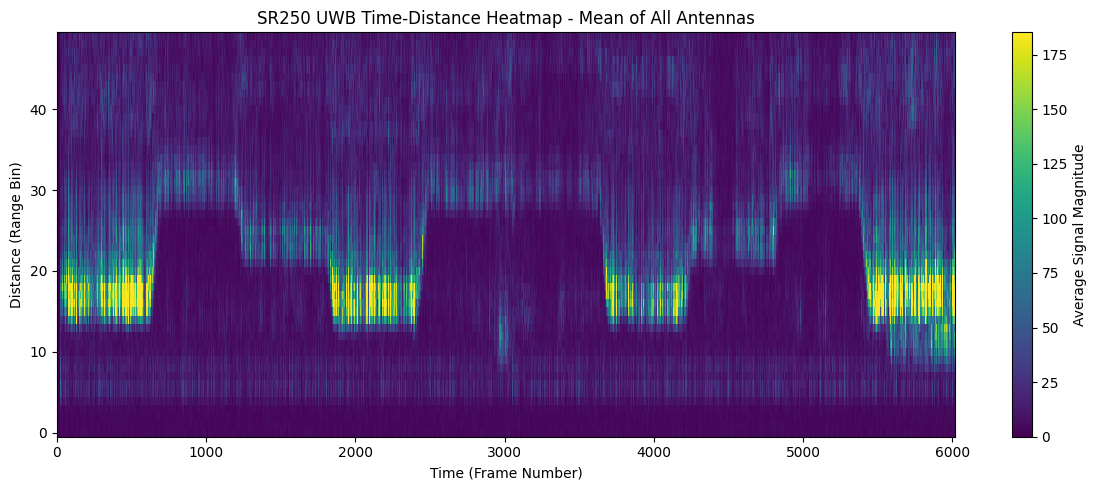

[array([[  0.        +0.j       ,   0.        +0.j       ,
           0.        +0.j       , ...,   0.        +0.j       ,
           0.        +0.j       ,   0.        +0.j       ],
        [  0.        +0.j       ,   0.        +0.j       ,
           0.        +0.j       , ...,   0.        +0.j       ,
           0.        +0.j       ,   0.        +0.j       ],
        [  0.        +0.j       ,   0.        +0.j       ,
           0.        +0.j       , ...,   0.        +0.j       ,
           0.        +0.j       ,   0.        +0.j       ],
        ...,
        [ -0.8999996 -9.5j      ,  -5.450012  -3.6999998j,
          -9.300049  +6.6500015j, ..., -16.449997 -27.550018j ,
         -40.800003 -24.350006j , -23.300003  -7.4500046j],
        [ -3.75      +3.25j     ,  -1.3999939 +3.8999996j,
          -2.8000488 -0.5j      , ...,   2.8499908-21.649994j ,
         -20.949997 -17.800003j , -18.850006  -5.6500015j],
        [ -4.800001  -5.6499996j,  -5.350006  -8.8j      ,
          -5.

In [9]:
print("--- Running original visualizations ---")
visualise_sr250("/kaggle/input/datasets-uwb/SR250Mate/(move)2-12-9-3-13-14-4-8-13-2_Still position_20250618-152004_sr250_rx0.npy")

## Apply Digital Beamforming

In [66]:
# --- Radar Parameters ---
d = 2.4e-2             # Distance between rx antenna elements for azimuth (rx0 and rx1)
f = 7.25e9           # Center frequency of radar pulse
c = 299792458        # Speed of light

l = c/f              # Wavelength
k = 2*np.pi/l        # Wavenumber

# Beam steering angles for azimuth
min_angle = -60
max_angle = 60
num_angles = max_angle - min_angle + 1 # Default resolution of 1°
beam_steering_angles = np.deg2rad(np.linspace(min_angle, max_angle, num_angles))



In [11]:
# --- Beamforming Helper Functions ---
def compute_bf_weights(angle_range, delta, k, num_rx_elements):
    """
    Computes beamforming weights for a linear array.
    
    Args:
        angle_range (np.ndarray): Array of angles (in radians) for which to compute weights.
        delta (float): Distance between adjacent antenna elements.
        k (float): Wavenumber (2*pi/lambda).
        num_rx_elements (int): Number of receive antenna elements.
        
    Returns:
        np.ndarray: Beamforming weights of shape (len(angle_range), num_rx_elements).
    """
    bf_weights = np.zeros((angle_range.shape[0], num_rx_elements), dtype="complex")
    for i in range(angle_range.shape[0]):      # Loop over angles
        for j in range(num_rx_elements):       # Loop over antenna elements
            # Phase shift for element j at angle_range[i]
            bf_weights[i, j] = np.exp(-1j * k * delta * j * np.sin(angle_range[i]))
    return bf_weights

In [12]:
def perform_azimuth_beamforming(rx0_complex_data, rx1_complex_data, d, k, beam_steering_angles):
    """
    Performs azimuth beamforming on complex data from rx0 and rx1 antennas.
    This version processes all time frames individually, producing a 3D output.
    
    Args:
        rx0_complex_data (np.ndarray): Complex CIRs from rx0 (time_frames, range_bins).
        rx1_complex_data (np.ndarray): Complex CIRs from rx1 (time_frames, range_bins).
        d (float): Distance between rx0 and rx1 antennas (element spacing).
        k (float): Wavenumber (2*pi/lambda).
        beam_steering_angles (np.ndarray): Array of angles in radians for beamsteering.

    Returns:
        np.ndarray: Beamformed data of shape (time_frames, range_bins, angles), or None if error.
    """
    
    if rx0_complex_data is None or rx1_complex_data is None:
        print("Error: Input data for beamforming is missing.")
        return None
    if rx0_complex_data.shape != rx1_complex_data.shape:
        print("Error: rx0 and rx1 data shapes do not match. Cannot perform beamforming.")
        return None
    else:
        print(f"Shape of the complex input data (rx0/rx1): {rx0_complex_data.shape}, with dtype {rx0_complex_data.dtype}")

    num_time_frames = rx0_complex_data.shape[0]   # Slow time
    num_range_bins = rx0_complex_data.shape[1]    # Fast time
    num_rx_elements = 2                           # For azimuth, using rx0 and rx1
    num_angles = beam_steering_angles.shape[0]    # Number of angles to be considered

    # Compute beamforming weights. These are constant for all time frames and range bins.
    bf_weights = compute_bf_weights(beam_steering_angles, d, k, num_rx_elements)

    # Initialize a 3D array to store beamformed results
    beamformed_3d_result = np.zeros((num_time_frames, num_range_bins, num_angles), dtype=complex)
    print(f"Starting beamforming over {num_time_frames} time frames and {num_range_bins} range bins...")

    # This version performs the same carried out by bf.py but exploiting NumPY vectorized operations.
    for t in range(num_time_frames):
        # Extract the complex CIRs for the current time frame from both RX antennas       
        # and stack them to form the input for beamforming for the current frame.
        # data_for_current_frame_all_bins will have shape (num_rx_elements, range_bins)
        data_for_current_frame_all_bins = np.stack([rx0_complex_data[t, :], rx1_complex_data[t, :]], axis=0)

        # Perform matrix multiplication for all range bins in the current frame simultaneously
        # (num_angles, num_rx_elements) @ (num_rx_elements, num_range_bins)
        # Result of dot product: (num_angles, num_range_bins)
        beamformed_slice_transposed = np.dot(bf_weights, data_for_current_frame_all_bins)
        
        # Transpose the result to get (range_bins, angles) for this time slice
        beamformed_3d_result[t, :, :] = beamformed_slice_transposed.T
            
    print("Beamforming complete for all frames and range bins.")
    return beamformed_3d_result

In [103]:
def show_range_angle_plot(matrix, angles_rad, title="Beamformed Range-Azimuth Image", range_conversion_factor=10, output_path= "/kaggle/working/dataset_fomo/"):
    """
    Visualizes the beamformed data as a 2D heatmap (Distance vs. Azimuth Angle).
    Converts range bins to meters for visualization.
    
    Args:
        matrix (np.ndarray): The beamformed data, shape (range_bins, angles).
                              This should be the magnitude for plotting.
        angles_rad (np.ndarray): Array of angles in radians used for beamsteering.
        title (str): Title for the plot.
        range_conversion_factor (int/float): Number of bins per meter.

        It also saves the plot as a .png image without axis nor title
    """
    output_path= f"/kaggle/working/{title}"

    # Dimensioni dell'immagine di output (es. 160x160, un formato comune per Edge Impulse)
    OUTPUT_IMAGE_SIZE = (160, 160) # (larghezza, altezza)

    # Parametri del modello FOMO
    FOMO_GRID_SIZE = (20, 20) # (altezza, larghezza) -> (distanza, angolo) -> deve essere un divisore di OUTPUT_IMAGE_SIZE
    OBJECT_CLASS_ID = 0
    print("Generating Beamformed plot...\n")

    dpi = 100
    fig_width = OUTPUT_IMAGE_SIZE[0] / dpi
    fig_height = OUTPUT_IMAGE_SIZE[1] / dpi
    
    heatmap_data = matrix
    fig, ax = plt.subplots(figsize=(12, 16))

    angles_deg = np.rad2deg(angles_rad)

    # Convert range bins to meters for the y-axis extent
    min_range_meters = 0
    max_range_meters = heatmap_data.shape[0] / range_conversion_factor # (number of range bins) / (bins per meter)

    # extent defines (left, right, bottom, top) in data coordinates
    # For imshow: x-axis maps to columns, y-axis maps to rows.
    # matrix is (rows=range_bins, cols=angles) -> extent = [x_min, x_max, y_min, y_max]
    extent = [angles_deg.min(), angles_deg.max(), min_range_meters, max_range_meters] 

    im = ax.imshow(
        heatmap_data, 
        aspect='auto', 
        origin='lower', # Origin lower for distance on Y-axis (0 at bottom)
        cmap='viridis',
        interpolation='nearest',
        vmin=np.percentile(heatmap_data, 10),
        vmax=np.percentile(heatmap_data, 99),
        extent=extent # Map data coordinates to image pixels
    )
    #just to save the image
    ax.axis('off')
    fig.savefig(output_path, bbox_inches='tight', pad_inches=0, dpi=dpi)
    
    ax.axis('on')
    ax.set_title(title)
    ax.set_xlabel("Azimuth Angle (degrees)")
    ax.set_ylabel("Distance (meters)") # Changed label to meters
    fig.colorbar(im, ax=ax, label="Beamformed Signal Magnitude")
    
    # Set x-axis ticks to display angles more meaningfully
    num_ticks_x = 7 # Example, adjust as needed
    tick_indices_x = np.linspace(0, len(angles_deg) - 1, num_ticks_x).astype(int)
    ax.set_xticks(angles_deg[tick_indices_x])
    ax.set_xticklabels([f"{a:.0f}°" for a in angles_deg[tick_indices_x]])

    # Set y-axis ticks to display meters more meaningfully
    # Determine appropriate interval for y-axis ticks based on max_range_meters
    if max_range_meters <= 1:
        y_tick_interval = 0.1
    elif max_range_meters <= 5:
        y_tick_interval = 0.5
    else:
        y_tick_interval = 1.0
    
    y_ticks = np.arange(min_range_meters, max_range_meters + y_tick_interval, y_tick_interval)
    ax.set_yticks(y_ticks)
    ax.set_yticklabels([f"{d:.1f}m" for d in y_ticks])
    
    

    plt.tight_layout()
    plt.show()
    
    #fig.savefig(output_path, bbox_inches='tight', pad_inches=0, dpi=dpi)
    plt.close(fig)

In [14]:
def normalize_range_angle_map(matrix: np.ndarray) -> np.ndarray:
    """
    Normalizes a 2D Range-Angle map to the range [0, 1] using min-max scaling,
    as described in Equation (11) of the thesis.

    Args:
        matrix (np.ndarray): The input 2D Range-Angle map.

    Returns:
        np.ndarray: The normalized map.
    """
    min_val = np.min(matrix)
    max_val = np.max(matrix)
    if max_val == min_val: # Avoid division by zero for uniform matrices
        return np.zeros_like(matrix)
    normalized_matrix = (matrix - min_val) / (max_val - min_val)
    return normalized_matrix

In [107]:
def apply_bf_pipeline (base_file, rx_s = [0, 2], coherent_incoherent_avg = 1, one= False):
    
    # Load and declutter data for all antennas
    print(f"\n--- Loading and processing data for beamforming: {os.path.basename(base_file)} ---")
    all_complex_data = visualise_sr250(base_file)

    # Check if rx0 and rx1 data are available for azimuth beamforming.
    rx0_data = all_complex_data[rx_s[0]]
    rx1_data = all_complex_data[rx_s[1]]
    #discard first 20 samples
    rx0_data = rx0_data[20:]
    rx1_data =rx1_data[20:]
    # Perform azimuth beamforming, return a 3D array (time_frames, range_bins, angles)
    print(f"Performing azimuth beamforming using RX{rx_s[0]} and RX{rx_s[1]} data...")
    beamformed_3d_data = perform_azimuth_beamforming(rx0_data, rx1_data, d, k, beam_steering_angles)
    print(f"Shape of the beamformed data: {beamformed_3d_data.shape} with dtype {beamformed_3d_data.dtype}")
    
    # Aggregate the 3D data for 2D visualization (Range-Azimuth Heatmap)
    if beamformed_3d_data is not None and not one:
        for i in range(4, 0, -1):
            #target_time_frame = round(beamformed_3d_data.shape[0] / i)
            target_time_frame= 10 * i
            start_point= 20
            
            if coherent_incoherent_avg == 0:
                # Coherent averaging
                print("Apply coherent averaging...")
                aggregated_beamformed_data = np.abs(np.sum(beamformed_3d_data[start_point:target_time_frame + 1, :, ], axis=0))
            elif coherent_incoherent_avg == 1:
                # Incoherent averaging
                print("Apply incoherent averaging...")
                aggregated_beamformed_data = np.sum(np.abs(beamformed_3d_data[start_point:target_time_frame + 1, :, ]), axis=0)
            else:
                # Incoherent averaging with mean
                print("Apply incoherent averaging by mean...")
                aggregated_beamformed_data = np.mean(np.abs(beamformed_3d_data[start_point:target_time_frame + 1, :, ]), axis=0)
            # Normalization
        
            normalized_beamformed_data = normalize_range_angle_map(aggregated_beamformed_data)
            title = f"Beamforming ({target_time_frame} time frames) - {os.path.basename(base_file).replace('_sr250_rx0.npy', '')}"
            
            show_range_angle_plot(normalized_beamformed_data, beam_steering_angles, title)
    elif one:
            target_time_frame= 40
            aggregated_beamformed_data = np.abs(np.sum(beamformed_3d_data[:target_time_frame + 1, :, ], axis=0))
            normalized_beamformed_data = normalize_range_angle_map(aggregated_beamformed_data)
            title = f"Beamforming ({target_time_frame} time frames) - {os.path.basename(base_file).replace('_sr250_rx0.npy', '')}"
            
            show_range_angle_plot(normalized_beamformed_data, beam_steering_angles, title)
    else:
        print("Beamforming could not be completed.")


--- Loading and processing data for beamforming: 14_Still position_20250618-112731_sr250_rx0.npy ---
Processing 14_Still position_20250618-112731_sr250_rx0.npy...
Processing 14_Still position_20250618-112731_sr250_rx1.npy...
Processing 14_Still position_20250618-112731_sr250_rx2.npy...


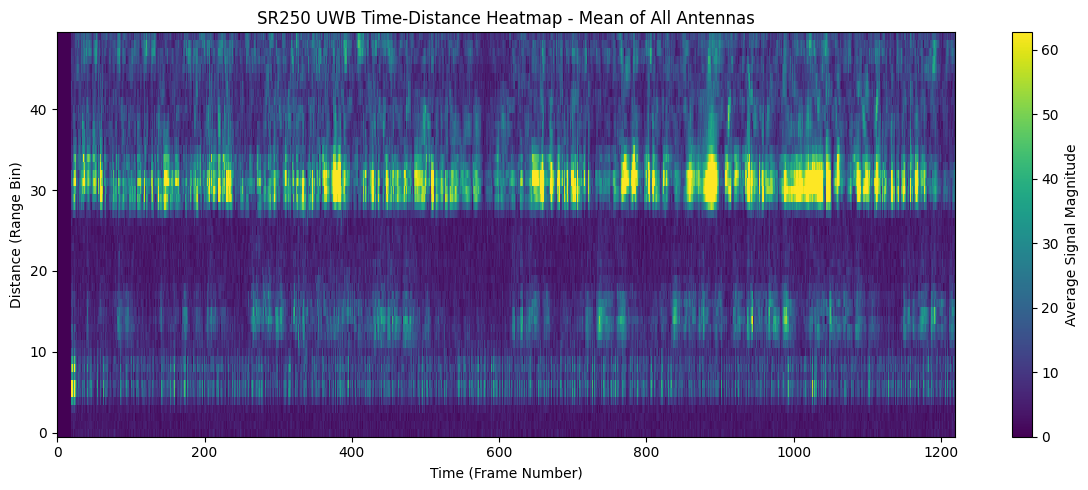

Performing azimuth beamforming using RX0 and RX1 data...
Shape of the complex input data (rx0/rx1): (1200, 50), with dtype complex64
Starting beamforming over 1200 time frames and 50 range bins...
Beamforming complete for all frames and range bins.
Shape of the beamformed data: (1200, 50, 121) with dtype complex128
Apply incoherent averaging...
Generating Beamformed plot...



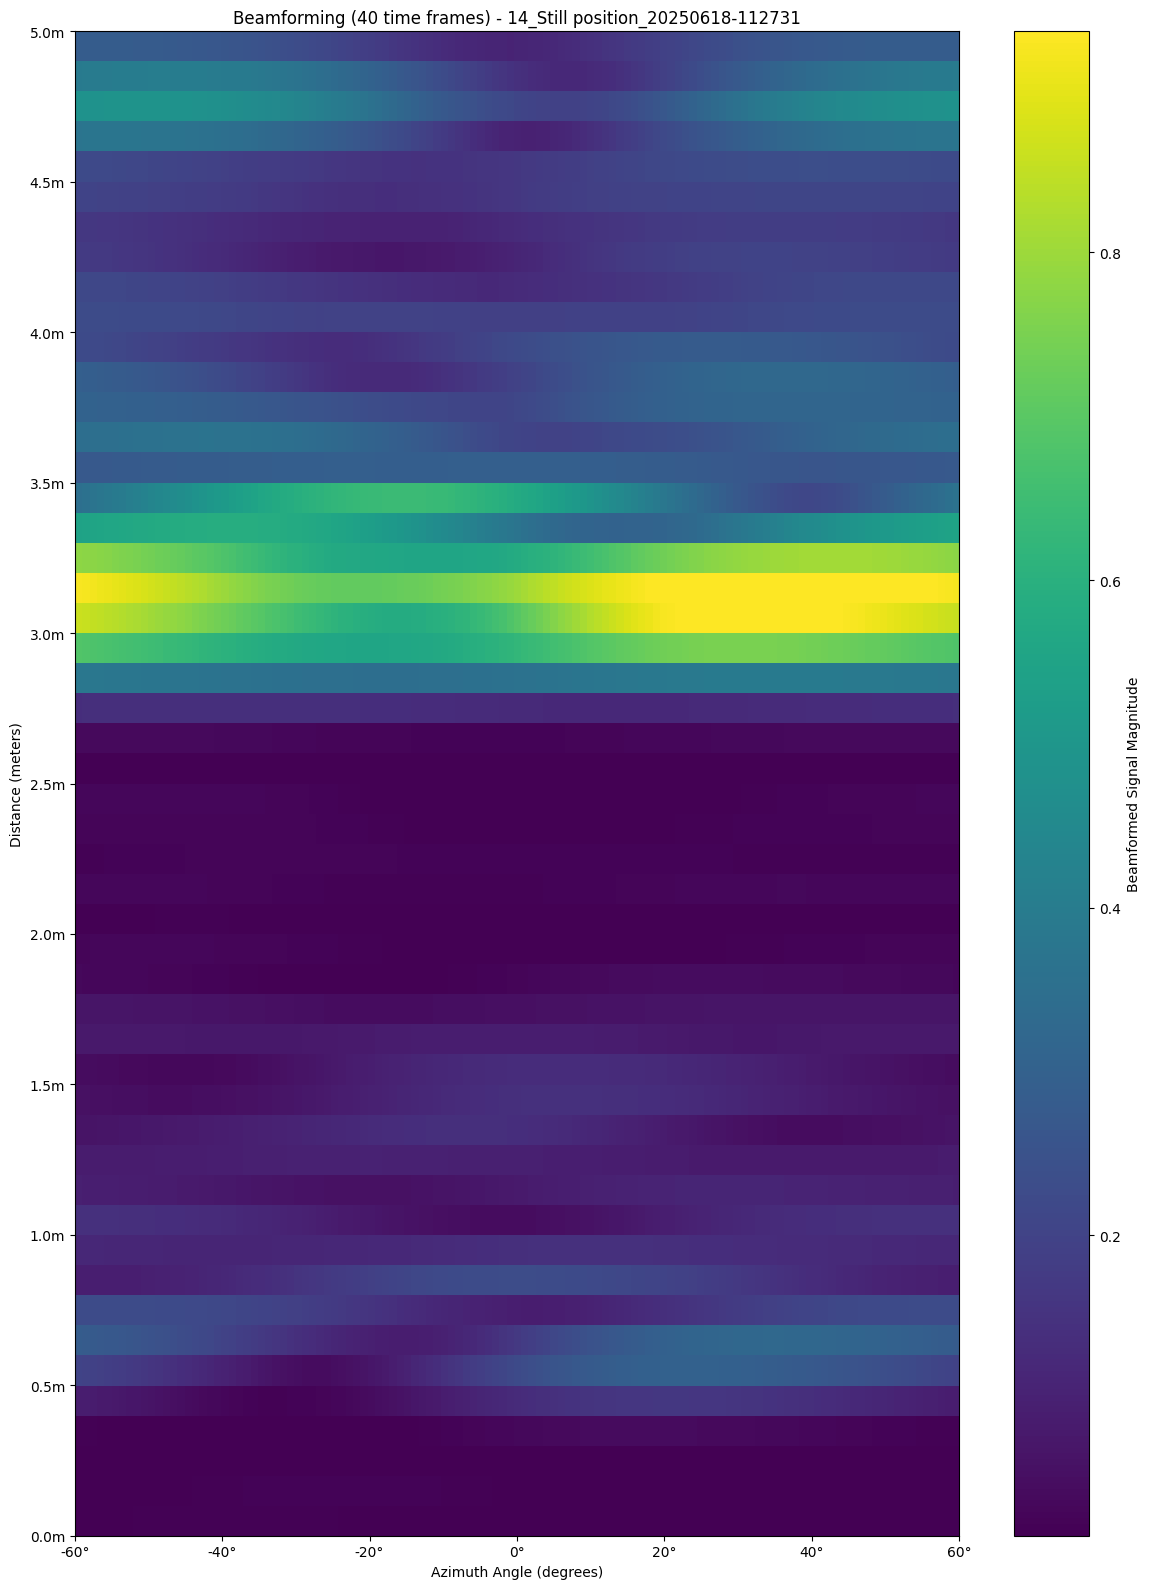

Apply incoherent averaging...
Generating Beamformed plot...



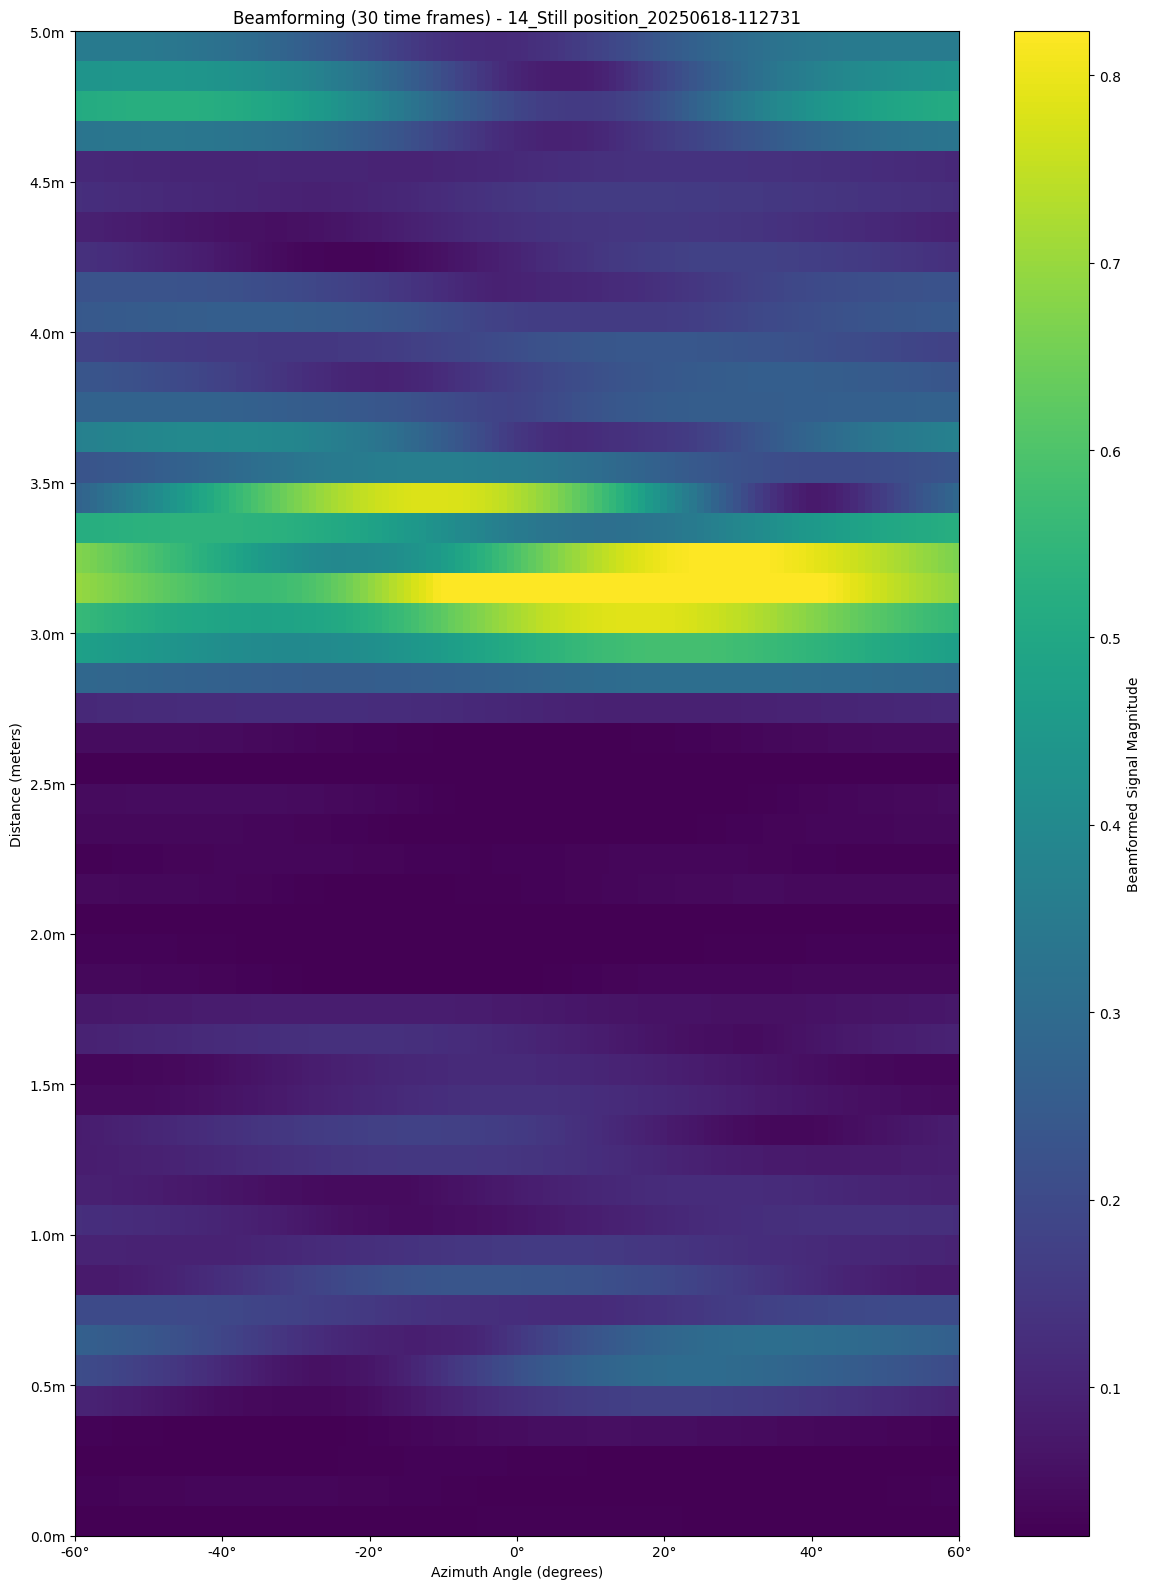

Apply incoherent averaging...
Generating Beamformed plot...



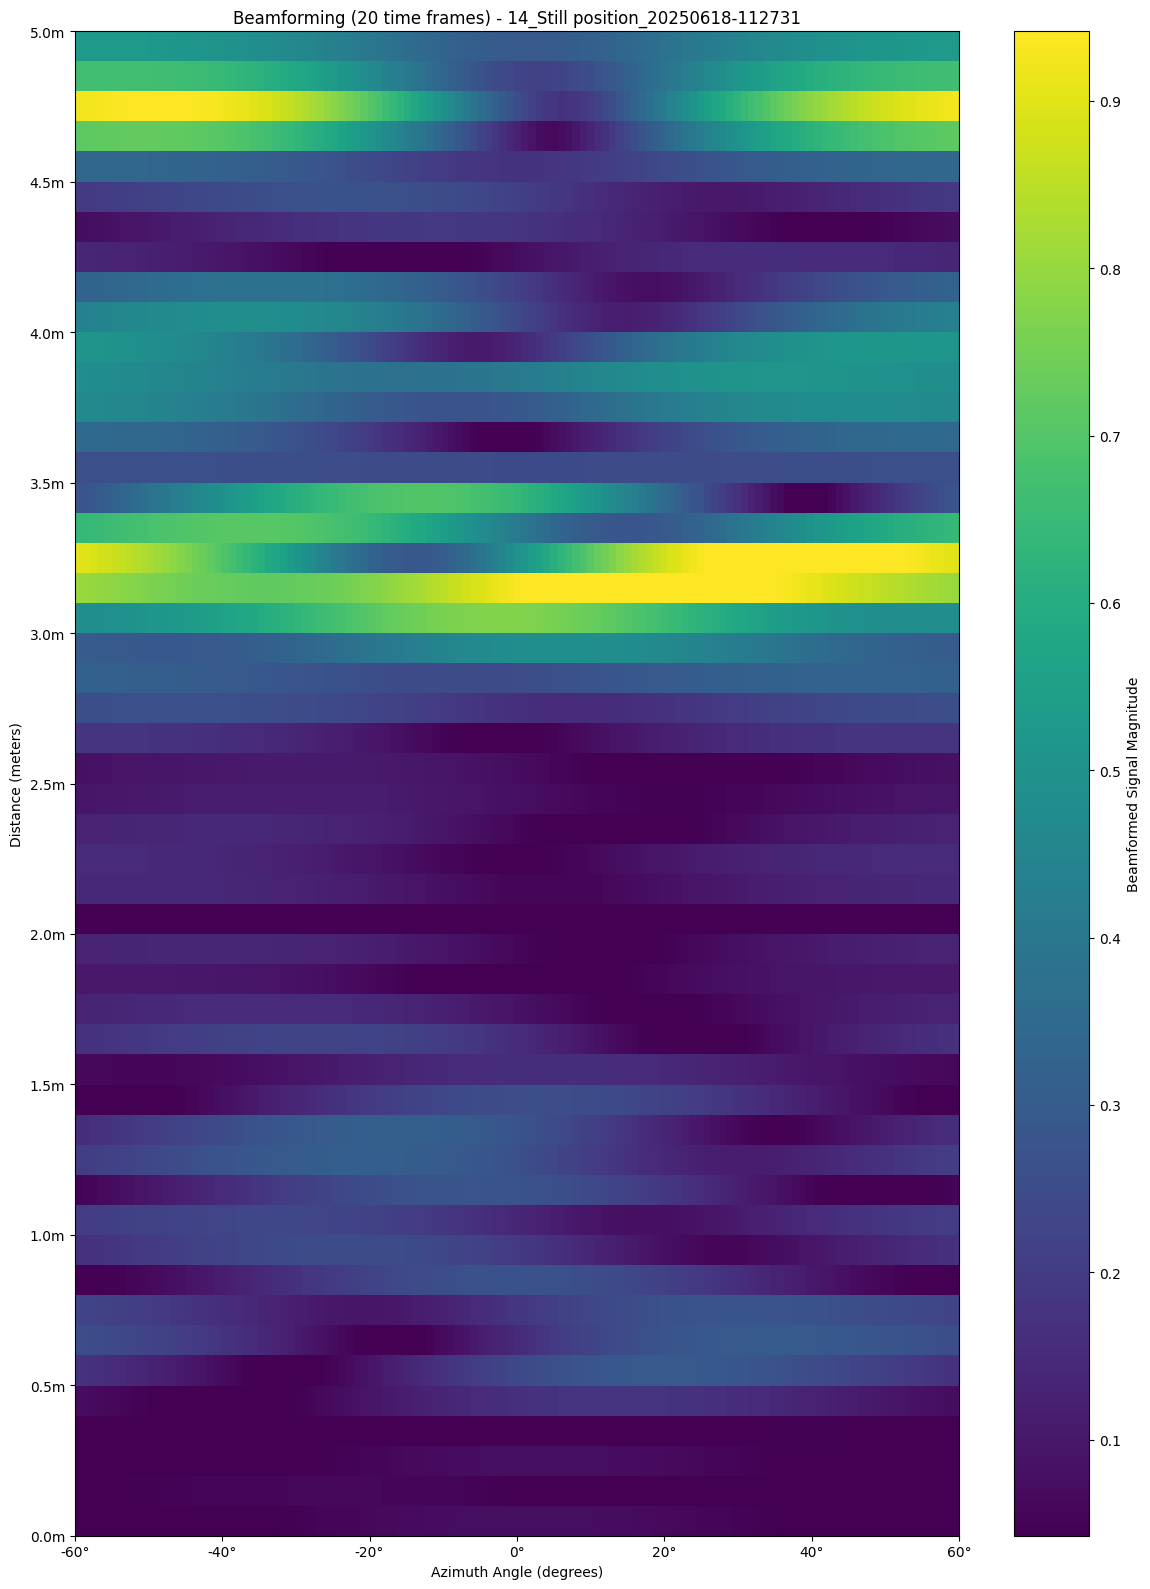

Apply incoherent averaging...
Generating Beamformed plot...



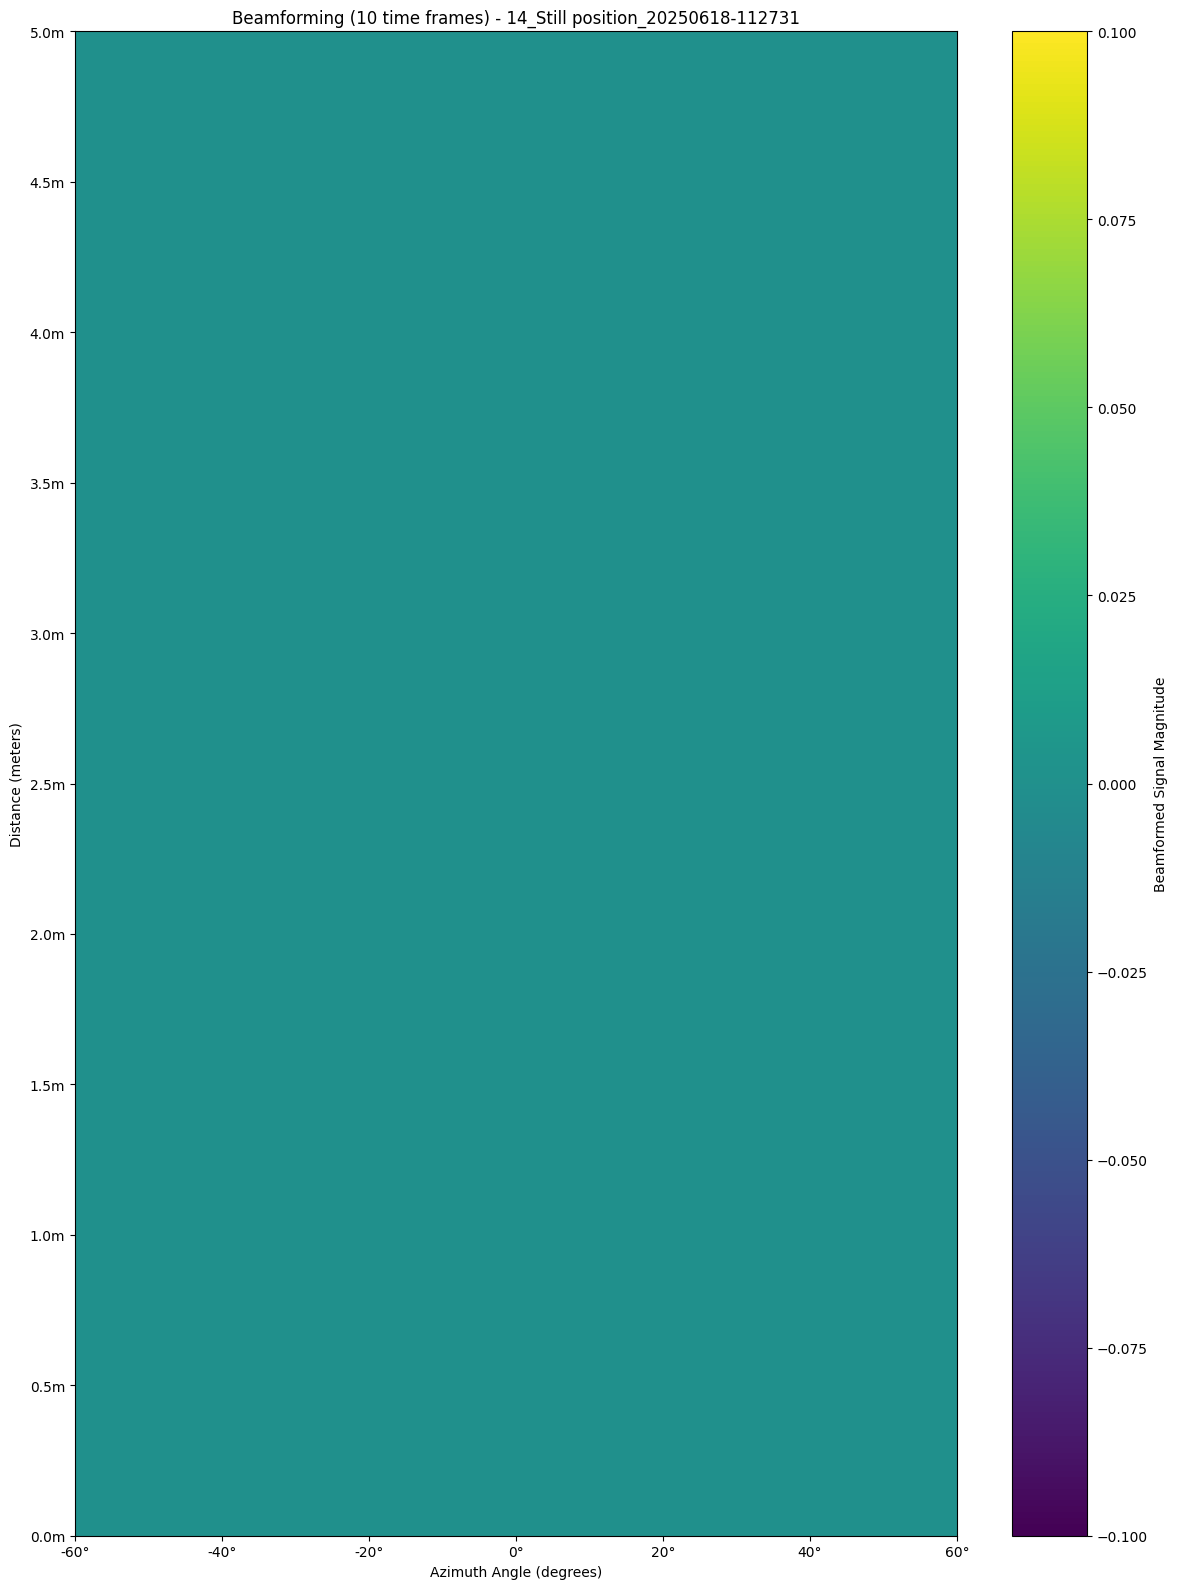

In [108]:
base_file_for_bf = "/kaggle/input/sr250mate-dataset/SR250Mate/14_Still position_20250618-112731_sr250_rx0.npy"
apply_bf_pipeline(base_file_for_bf, [0, 1], 1)

# DEFINE TRAINING DATASET


In [92]:
#taken from data collection set up
GROUND_TRUTH_POSITIONS = {
    2: {'distance': 1.5, 'angle': -45.0},
    3: {'distance': 1.5, 'angle': 0.0},
    4: {'distance': 1.5, 'angle': 45.0},
    7: {'distance': 2.5, 'angle': -45.0},
    8: {'distance': 2.5, 'angle': 0.0},
    9: {'distance': 2.5, 'angle': 45.0},
    12: {'distance': 3.5, 'angle': -45.0},
    13: {'distance': 3.5, 'angle': 0.0},
    11: {'distance': 3.5, 'angle': 45.0},
    14: {'distance': 3.5, 'angle': 15.0} 
}

DISTANCE_MIN=0
DISTANCE_MAX=5
FOMO_GRID_SIZE = (16, 16) # (altezza, larghezza)
OBJECT_CLASS_ID = 0

In [64]:
def create_fomo_label(position_number, output_path):
    """
    Create a label for FOMO
    """
    if position_number not in GROUND_TRUTH_POSITIONS:
        print(f"  -> Attenzione: Posizione {position_number} non trovata. Salto etichetta.")
        return False

    gt = GROUND_TRUTH_POSITIONS[position_number]
    distance, angle = gt['distance'], gt['angle']

    # Normalizza le coordinate reali (distanza, angolo) in un range [0, 1]
    # y = distanza, x = angolo
    y_norm = (distance - DISTANCE_MIN) / (DISTANCE_MAX - DISTANCE_MIN)
    x_norm = (angle - min_angle) / (max_angle - min_angle)
    
    y_norm = np.clip(y_norm, 0.0, 1.0)
    x_norm = np.clip(x_norm, 0.0, 1.0)

    # Calcola dimensioni e centro della cella della griglia FOMO
    grid_h, grid_w = FOMO_GRID_SIZE
    box_w_norm = 1.0 / grid_w
    box_h_norm = 1.0 / grid_h
    
    grid_col = int(x_norm * grid_w)
    grid_row = int(y_norm * grid_h)
    
    x_center_norm = (grid_col + 0.5) / grid_w
    y_center_norm = (grid_row + 0.5) / grid_h

    # Formato etichetta: "class_id x_center y_center width height"
    label_str = f"{OBJECT_CLASS_ID} {x_center_norm:.6f} {y_center_norm:.6f} {box_w_norm:.6f} {box_h_norm:.6f}"
    
    with open(output_path, 'w') as f:
        f.write(label_str)
    
    return True

In [85]:
def create_label_from_png(image_path, label_path):
    """
    Analyze an image of heatmap, finding the "lighter spot"
    """
    try:
        # 1. Carica l'immagine e ottieni le sue dimensioni
        with Image.open(image_path) as img:
            img_width, img_height = img.size
            
            # 2. Converti l'immagine in scala di grigi ('L' mode)
            # I colori più luminosi (come il giallo) avranno valori più alti.
            grayscale_img = img.convert('L')
            
            # Converti l'immagine in una matrice NumPy per l'analisi
            heatmap_data = np.array(grayscale_img)

    except FileNotFoundError:
        print(f"  -> ERRORE: Immagine non trovata in '{image_path}'.")
        return False
    except Exception as e:
        print(f"  -> ERRORE durante il caricamento o la conversione dell'immagine '{os.path.basename(image_path)}': {e}")
        return False

    # 3. Trova le coordinate (riga, colonna) del pixel più luminoso
    peak_coords_pixels = np.unravel_index(np.argmax(heatmap_data), heatmap_data.shape)
    peak_row, peak_col = peak_coords_pixels
    
    # 4. Normalizza le coordinate del pixel in un range [0, 1]
    # L'asse Y (verticale) corrisponde alle righe, l'asse X (orizzontale) alle colonne.
    y_norm = peak_row / img_height
    x_norm = peak_col / img_width
    
    # 5. Calcola le informazioni della cella della griglia FOMO
    grid_h, grid_w = FOMO_GRID_SIZE
    box_w_norm = 1.0 / grid_w
    box_h_norm = 1.0 / grid_h
    
    grid_col = int(x_norm * grid_w)
    grid_row = int(y_norm * grid_h)
    
    x_center_norm = (grid_col + 0.5) / grid_w
    y_center_norm = (grid_row + 0.5) / grid_h

    # 6. Formatta e salva il file di etichetta
    label_str = f"{OBJECT_CLASS_ID} {x_center_norm:.6f} {y_center_norm:.6f} {box_w_norm:.6f} {box_h_norm:.6f}"
    
    try:
        with open(label_path, 'w') as f:
            f.write(label_str)
        return True
    except IOError as e:
        print(f"  -> ERRORE nella scrittura del file di etichetta {label_path}: {e}")
        return False

In [88]:
def visualize_sample(dataset_dir="/kaggle/working", filename=None):
    """
    Visualize the bounding box
    """
    
    # Trova tutti i file immagine nel dataset
    image_files = [f for f in os.listdir(dataset_dir) if f.endswith(".png")]
    
    if not image_files:
        print(f"Nessun file .png trovato in '{dataset_dir}'")
        return

    # Se non è specificato un file, scegline uno a caso
    if filename is None:
        selected_image_file = random.choice(image_files)
    else:
        if filename not in image_files:
            print(f"File '{filename}' non trovato nel dataset. Scelgo uno a caso.")
            selected_image_file = random.choice(image_files)
        else:
            selected_image_file = filename

    # Definisci i percorsi per l'immagine e l'etichetta
    base_name = "label"
    image_path = os.path.join(dataset_dir, selected_image_file)
    label_path = os.path.join(dataset_dir, f"{base_name}.txt")

    print(f"Visualizzazione del campione: {selected_image_file}")

    # --- Carica l'immagine ---
    try:
        img = Image.open(image_path)
        img_width, img_height = img.size
    except FileNotFoundError:
        print(f"Errore: File immagine non trovato in '{image_path}'")
        return

    # --- Carica e processa l'etichetta ---
    try:
        with open(label_path, 'r') as f:
            line = f.readline()
            # Il formato è: class_id x_center_norm y_center_norm width_norm height_norm
            parts = line.strip().split()
            class_id = int(parts[0])
            x_center_norm = float(parts[1])
            y_center_norm = float(parts[2])
            width_norm = float(parts[3])
            height_norm = float(parts[4])

            # --- Converti le coordinate normalizzate in coordinate pixel ---
            # Calcola le dimensioni del box in pixel
            box_width = width_norm * img_width
            box_height = height_norm * img_height

            # Calcola le coordinate dell'angolo in alto a sinistra del box
            x_min = (x_center_norm * img_width) - (box_width / 2)
            y_min = (y_center_norm * img_height) - (box_height / 2)

    except FileNotFoundError:
        print(f"Etichetta non trovata per '{selected_image_file}'. Mostro solo l'immagine.")
        x_min, y_min, box_width, box_height = None, None, None, None
    except (IOError, IndexError, ValueError) as e:
        print(f"Errore nella lettura del file di etichetta '{label_path}': {e}")
        return

    # --- Disegna l'immagine e il bounding box ---
    fig, ax = plt.subplots(1, figsize=(8, 8))
    ax.imshow(img)
    
    # Se l'etichetta è stata caricata correttamente, disegna il rettangolo
    if x_min is not None:
        # Crea una patch rettangolare
        # Nota: Matplotlib si aspetta (x, y) dell'angolo in basso a sinistra
        rect = patches.Rectangle(
            (x_min, y_min), 
            box_width, 
            box_height, 
            linewidth=2, 
            edgecolor='r',  # Colore rosso per una buona visibilità
            facecolor='none'
        )
        
        # Aggiungi il rettangolo all'immagine
        ax.add_patch(rect)

        # Aggiungi un'etichetta di testo (opzionale)
        plt.text(x_min, y_min - 10, f'ID: {class_id}', color='red', fontsize=12, 
                 bbox=dict(facecolor='white', alpha=0.5, pad=1))

    ax.set_title(f"Verifica: {selected_image_file}")
    ax.axis('off')  # Nascondi gli assi per una visualizzazione pulita
    plt.show()


label created
Visualizzazione del campione: Beamforming (40 time frames) - 14_Still position_20250618-112731.png


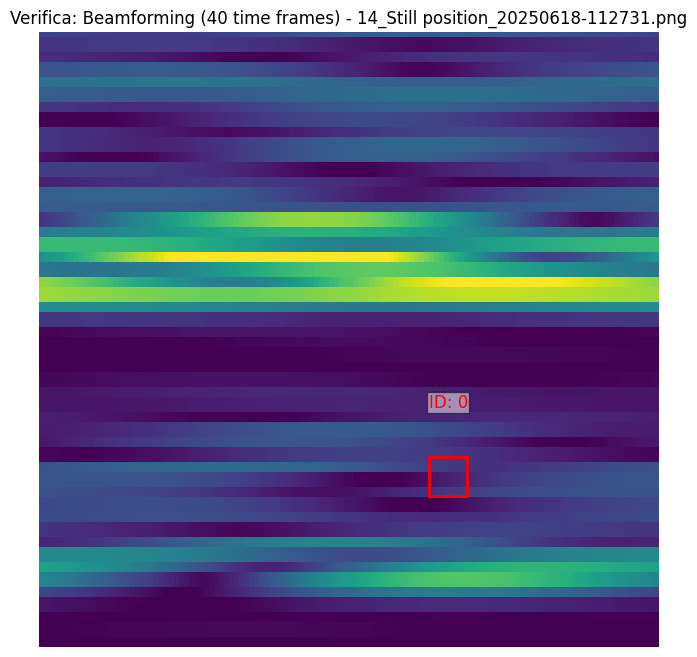

In [99]:
if create_label_from_png("/kaggle/working/Beamforming (40 time frames) - 14_Still position_20250618-112731.png","/kaggle/working/label_14_still_position.txt"):
    print("label created")
    visualize_sample(filename="Beamforming (40 time frames) - 14_Still position_20250618-112731.png")

label created
Visualizzazione del campione: Beamforming (40 time frames) - 14_Still position_20250618-112731.png


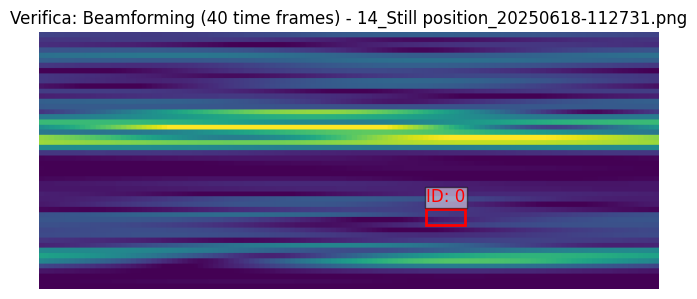

In [93]:
if create_fomo_label(14,"/kaggle/working/label.txt"):
    print("label created")
    visualize_sample(filename="Beamforming (40 time frames) - 14_Still position_20250618-112731.png")

In [ ]:
def doppler_processing(data, prf, window_fn=np.hanning):
    """
    Perform Doppler FFT along time axis of beamformed radar data.

    Parameters:
        data : np.ndarray
            Complex beamformed data, shape (time_frames, range_bins, angle_bins)
        prf : float
            Pulse Repetition Frequency (Hz)
        window_fn : callable
            Window function to reduce sidelobes, default: np.hanning

    Returns:
        doppler_cube : np.ndarray
            Doppler spectrum cube, shape (doppler_bins, range_bins, angle_bins)
        doppler_freqs : np.ndarray
            Doppler frequency bins (Hz), shape (doppler_bins,)
    """
    time_frames = data.shape[0]
    
    # Apply window to time axis to reduce sidelobes
    window = window_fn(time_frames).reshape(-1, 1, 1)
    windowed_data = data * window

    # Doppler FFT along time axis
    doppler_cube = np.fft.fftshift(
        np.fft.fft(windowed_data, axis=0), 
        axes=0
    )

    # Normalize magnitude
    doppler_cube = np.abs(doppler_cube)

    # Compute Doppler frequency bins
    doppler_freqs = np.fft.fftshift(
        np.fft.fftfreq(time_frames, d=1.0/prf)
    )

    return doppler_cube, doppler_freqs


In [ ]:

 #trying to aggregate by summing magnitudes for moving file

if beamformed_3d_data is not None:
    for i in range(4, 0, -1):
        target_time_frame = round(beamformed_3d_data.shape[0] / i)
        # doppler 
        doppler_data, _ = doppler_processing(beamformed_3d_data, prf=f)
        aggregated_beamformed_data = np.max(doppler_data[:target_time_frame + 1, :,],axis=0)
        #aggregated_beamformed_data = np.sum(np.abs(beamformed_3d_data[:target_time_frame + 1, :,]),axis=0)
        # Normalization
        normalized_beamformed_data = normalize_range_angle_map(aggregated_beamformed_data)
        title = f"Beamforming ({target_time_frame} time frames) - {os.path.basename(base_file_for_beamforming).replace('_sr250_rx0.npy', '')}"
        show_range_angle_plot(normalized_beamformed_data, beam_steering_angles, title)
else:
    print("Beamforming could not be completed.")